# TTC Delay Dataset Analysis Template

This notebook analyzes one TTC delay dataset file (CSV or Excel, even if extension is wrong).

How to use:
1. Change `FILE_PATH` in the next code cell.
2. Run all cells.
3. Review the generated tables and charts for insights.


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Change only this file path when you want to analyze a different year/file
# Examples: ../data/bus/<file>.csv, ../data/subway/<file>.csv, ../data/streetcar/<file>.csv
FILE_PATH = Path('../data/bus/ttc-bus-delay-data-2023__01_2023.csv')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')


In [ ]:
COLUMN_ALIASES = {
    'date': 'date',
    'report_date': 'date',
    'incident_date': 'date',
    'time': 'time',
    'report_time': 'time',
    'incident_time': 'time',
    'time_of_day': 'time',
    'route': 'route',
    'route_number': 'route',
    'route_name': 'route',
    'route_no': 'route',
    'route_num': 'route',
    'line': 'route',
    'location': 'location',
    'location_name': 'location',
    'intersection': 'location',
    'incident': 'incident',
    'incident_type': 'incident',
    'incident_description': 'incident',
    'delay_reason': 'incident',
    'min_delay': 'min_delay',
    'min delay': 'min_delay',
    'delay_minutes': 'min_delay',
    'delay': 'min_delay',
    'min_gap': 'min_gap',
    'min gap': 'min_gap',
    'gap_minutes': 'min_gap',
    'gap': 'min_gap',
    'day': 'day',
    'direction': 'direction',
    'vehicle': 'vehicle',
}

REQUIRED = ['date', 'time', 'route', 'location', 'incident', 'min_delay', 'min_gap']

def normalize_col(col: str) -> str:
    c = str(col).strip().strip('\"').replace('﻿', '').replace('​', '')
    c = c.replace('/', '_').replace('-', '_').lower()
    c = re.sub(r'[^a-z0-9_]+', '_', c)
    c = re.sub(r'_+', '_', c).strip('_')
    return COLUMN_ALIASES.get(c, c)

def read_any_table(file_path: Path) -> pd.DataFrame:
    payload = file_path.read_bytes()

    # xlsx files are zip containers starting with PK
    is_xlsx_payload = payload[:2] == b'PK'
    suffix = file_path.suffix.lower()

    if suffix in {'.xlsx', '.xls'} or is_xlsx_payload:
        return pd.read_excel(file_path)

    encodings = ('utf-8', 'utf-8-sig', 'utf-16', 'cp1252', 'latin1')
    seps = (None, ',', '\t', ';', '|')

    for enc in encodings:
        for sep in seps:
            try:
                return pd.read_csv(file_path, encoding=enc, sep=sep, engine='python', on_bad_lines='skip')
            except Exception:
                pass

    raise ValueError(f'Could not read file: {file_path}')

def standardize(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [normalize_col(c) for c in out.columns]

    # Build missing core columns with fuzzy fallbacks
    for target, patterns in {
        'date': ('date',),
        'time': ('time',),
        'route': ('route', 'line'),
        'location': ('location', 'intersection', 'stop'),
        'incident': ('incident', 'reason', 'cause'),
        'min_delay': ('delay',),
        'min_gap': ('gap',),
    }.items():
        if target in out.columns:
            continue
        match = next((c for c in out.columns if any(p in c for p in patterns)), None)
        if match is not None:
            out[target] = out[match]

    # If min_gap is absent, use min_delay as a fallback
    if 'min_gap' not in out.columns and 'min_delay' in out.columns:
        out['min_gap'] = out['min_delay']

    missing = [c for c in REQUIRED if c not in out.columns]
    if missing:
        raise ValueError(f'Missing required columns after standardization: {missing}')

    # Parse date/time and numeric fields
    out['date_parsed'] = pd.to_datetime(out['date'], errors='coerce')

    # Attempt to parse time directly; if fails, derive from date if datetime-like
    parsed_time = pd.to_datetime(out['time'].astype(str), errors='coerce')
    out['time_parsed'] = parsed_time.dt.time

    out['min_delay'] = pd.to_numeric(out['min_delay'], errors='coerce')
    out['min_gap'] = pd.to_numeric(out['min_gap'], errors='coerce')

    # Derive time-based dimensions for analysis
    out['year'] = out['date_parsed'].dt.year
    out['month'] = out['date_parsed'].dt.month
    out['day_name'] = out['date_parsed'].dt.day_name()

    hour_from_time = pd.to_datetime(out['time'].astype(str), errors='coerce').dt.hour
    hour_from_date = out['date_parsed'].dt.hour
    out['hour'] = hour_from_time.fillna(hour_from_date)

    return out


In [ ]:
if not FILE_PATH.exists():
    raise FileNotFoundError(f'File not found: {FILE_PATH.resolve()}')

raw_df = read_any_table(FILE_PATH)
df = standardize(raw_df)

print('Analyzed file:', FILE_PATH.resolve())
print('Raw shape:', raw_df.shape)
print('Standardized shape:', df.shape)

df.head()


C:\Users\awais\AppData\Local\Temp\ipykernel_16004\3895213272.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_time = pd.to_datetime(out['time'].astype(str), errors='coerce')
C:\Users\awais\AppData\Local\Temp\ipykernel_16004\3895213272.py:109: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hour_from_time = pd.to_datetime(out['time'].astype(str), errors='coerce').dt.hour


Analyzed file: D:\fSemester_2_Winter_(2026)\6414-Data Analytics and Visualization\Project\TTC-PULSE\ttc_delay_analytics\data\ttc-bus-delay-data-2023__01_2023.csv
Raw shape: (56207, 10)
Standardized shape: (56207, 16)


,date,route,time,day,location,incident,min_delay,min_gap,direction,vehicle,date_parsed,time_parsed,year,month,day_name,hour
0,2023-01-01,91,02:30,Sunday,WOODBINE AND MORTIMER,Diversion,81,111,NaN,8772,2023-01-01,02:30:00,2023,1,Sunday,2
1,2023-01-01,69,02:34,Sunday,WARDEN STATION,Security,22,44,S,8407,2023-01-01,02:34:00,2023,1,Sunday,2
2,2023-01-01,35,03:06,Sunday,JANE STATION,Cleaning - Unsanitary,30,60,N,1051,2023-01-01,03:06:00,2023,1,Sunday,3
3,2023-01-01,900,03:14,Sunday,KIPLING STATION,Security,17,17,NaN,3334,2023-01-01,03:14:00,2023,1,Sunday,3
4,2023-01-01,85,03:43,Sunday,MEADOWALE LOOP,Security,1,1,NaN,1559,2023-01-01,03:43:00,2023,1,Sunday,3


In [ ]:
# Data quality and descriptive statistics
missing_table = (
    df[REQUIRED]
    .isna()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda t: (100 * t['missing_count'] / len(df)).round(2))
)

display(missing_table)
display(df[['min_delay', 'min_gap']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


,missing_count,missing_pct
date,0,0.00
time,0,0.00
route,570,1.01
location,0,0.00
incident,0,0.00
min_delay,0,0.00
min_gap,0,0.00


,min_delay,min_gap
count,56207.000000,56207.000000
mean,20.251606,32.897557
std,50.170167,52.287433
min,0.000000,0.000000
50%,11.000000,21.000000
75%,20.000000,40.000000
90%,30.000000,56.000000
95%,40.000000,63.000000
99%,215.000000,241.000000
max,998.000000,992.000000


,incident,events,total_delay,avg_delay
2,Diversion,3805,405541,106.581078
7,Mechanical,19235,254643,13.238524
8,Operations - Operator,11360,159348,14.027113
4,General Delay,3199,75109,23.478900
10,Security,4807,54769,11.393593
1,Collision - TTC,3909,46706,11.948324
3,Emergency Services,3017,34543,11.449453
0,Cleaning - Unsanitary,2152,31452,14.615242
11,Utilized Off Route,2363,31300,13.245874
9,Road Blocked - NON-TTC Collision,249,14341,57.594378


,route,events,total_delay,avg_delay
85,32,1920,31927,16.628646
105,36,1697,29325,17.280495
144,52,1383,28193,20.385394
170,7,1250,22424,17.939200
73,29,1298,19780,15.238829
4,102,929,18949,20.397201
224,96,764,18670,24.437173
109,37,476,17997,37.808824
147,54,994,17956,18.064386
128,47,935,17819,19.057754


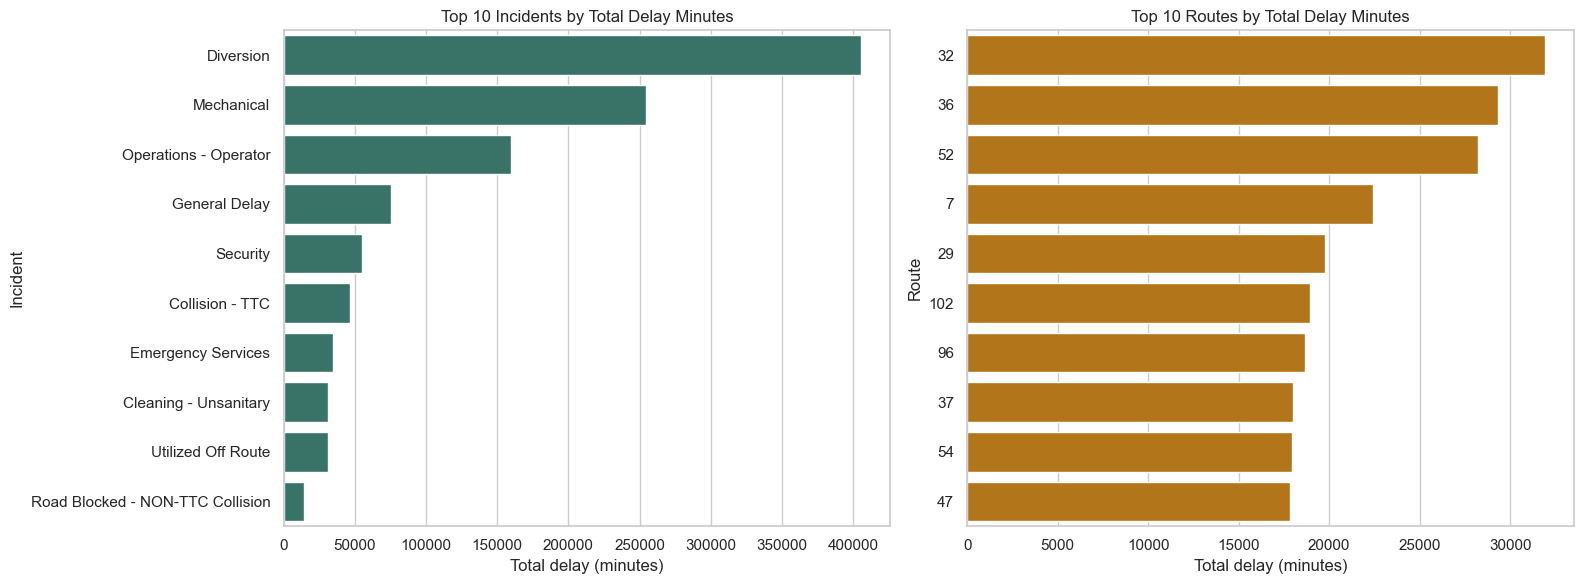

In [ ]:
# Top incidents and routes by delay impact
top_incidents = (
    df.dropna(subset=['incident'])
      .groupby('incident', as_index=False)
      .agg(events=('incident', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
      .head(10)
)

top_routes = (
    df.dropna(subset=['route'])
      .groupby('route', as_index=False)
      .agg(events=('route', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
      .head(10)
)

display(top_incidents)
display(top_routes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_incidents, y='incident', x='total_delay', ax=axes[0], color='#2f7d6d')
axes[0].set_title('Top 10 Incidents by Total Delay Minutes')
axes[0].set_xlabel('Total delay (minutes)')
axes[0].set_ylabel('Incident')

sns.barplot(data=top_routes, y='route', x='total_delay', ax=axes[1], color='#cc7a00')
axes[1].set_title('Top 10 Routes by Total Delay Minutes')
axes[1].set_xlabel('Total delay (minutes)')
axes[1].set_ylabel('Route')

plt.tight_layout()
plt.show()


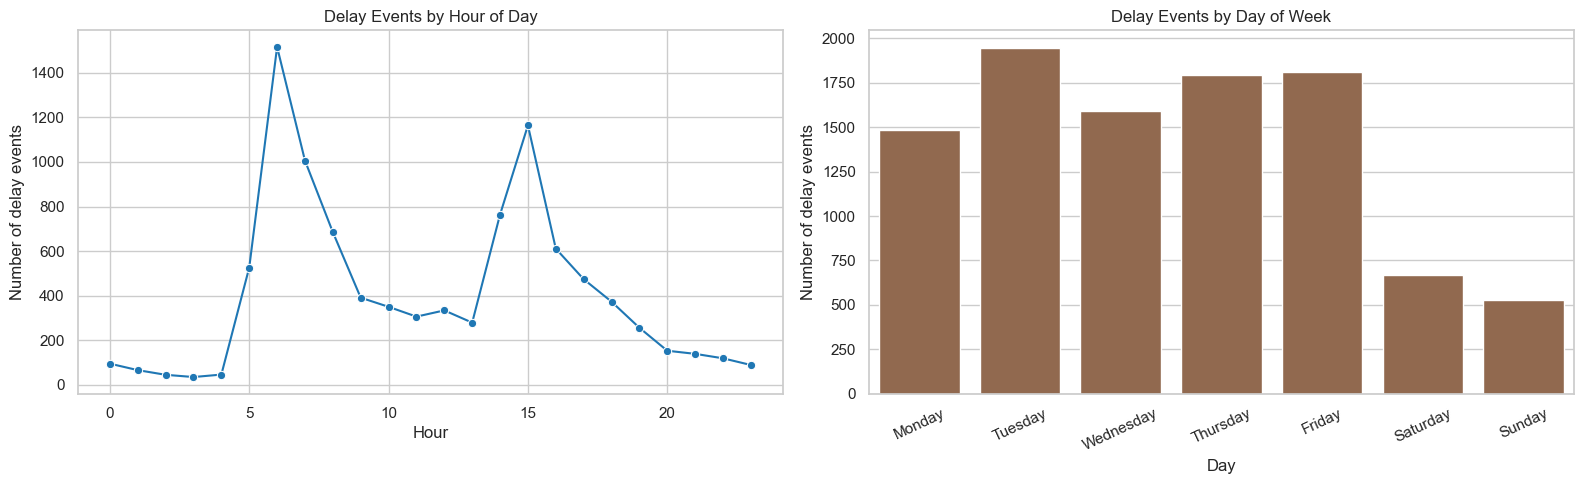

: 

In [ ]:
# Time-based patterns
hourly = (
    df.dropna(subset=['hour'])
      .groupby('hour', as_index=False)
      .agg(events=('hour', 'size'), avg_delay=('min_delay', 'mean'))
      .sort_values('hour')
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = (
    df.dropna(subset=['day_name'])
      .groupby('day_name', as_index=False)
      .agg(events=('day_name', 'size'), avg_delay=('min_delay', 'mean'))
)
daily['day_name'] = pd.Categorical(daily['day_name'], categories=day_order, ordered=True)
daily = daily.sort_values('day_name')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hourly, x='hour', y='events', marker='o', ax=axes[0], color='#1f77b4')
axes[0].set_title('Delay Events by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of delay events')

sns.barplot(data=daily, x='day_name', y='events', ax=axes[1], color='#9c6644')
axes[1].set_title('Delay Events by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of delay events')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


In [ ]:
# Top locations table and key numeric insights
top_locations = (
    df.dropna(subset=['location'])
      .groupby('location', as_index=False)
      .agg(events=('location', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
      .head(15)
)
display(top_locations)

valid_delay = df['min_delay'].dropna()
if len(valid_delay) > 0:
    print(f'Total records: {len(df):,}')
    print(f'Total delay minutes: {valid_delay.sum():,.0f}')
    print(f'Average delay minutes: {valid_delay.mean():.2f}')
    print(f'Median delay minutes: {valid_delay.median():.2f}')
    print(f'95th percentile delay minutes: {valid_delay.quantile(0.95):.2f}')
else:
    print('No valid min_delay values found.')


,location,events,total_delay,avg_delay
1205,Finch Station,139,1421.0,10.223022
2639,STEPHEN AND BERRY RD,1,1160.0,1160.000000
1122,Entire Route,83,919.0,11.072289
3204,Warden Station,63,910.0,14.444444
715,Downsview stn,149,897.0,6.020134
3342,Wilson Stn,183,861.0,4.704918
997,Eglinton stn,88,826.0,9.386364
1744,Kipling Station,78,804.0,10.307692
929,Eglinton Station,66,773.0,11.712121
2506,Ray and Weston,1,744.0,744.000000


Total records: 9,822
Total delay minutes: 124,223
Average delay minutes: 12.65
Median delay minutes: 9.00
95th percentile delay minutes: 30.00


: 